<a href="https://colab.research.google.com/github/aceiro/workflow-ml-gt-hc/blob/main/workflow_analise_GT%2BHC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Curso - MBA em Gestão de Negócios e Inteligência Artificial

## Aluno - Erik Aceiro

## Contexto

Esse notebook é parte do Trabalho Final de Conclusão de Curso do curso MBA em Gestão de Negócios e Inteligência Artificial.

No contexto desta pesquisa, foi utilizado a *Grounded Theory* combinada a *Hierarchical Clustering* (GT+HC) para identificar padrões recorrentes em funis de monetização da Economia dos Criadores.


**Similaridade de Jaccard**


> A similaridade entre os funis foi calculada por meio do coeficiente de Jaccard, amplamente utilizado para comparação de atributos binários e análise de padrões de coocorrência (TAN; STEINBACH; KUMAR, 2006).

**Hierarchical Clustering**

> Após o cálculo da similaridade entre os casos, foi aplicada a técnica de Hierarchical Clustering utilizando o método Average Linkage (UPGMA), permitindo a identificação de agrupamentos naturais entre os funis analisados (MÜLLNER, 2011).

## Referências

> TAN, Pang-Ning; STEINBACH, Michael; KUMAR, Vipin. Introduction to Data Mining. Boston: Pearson Addison Wesley, 2006. Disponível em: https://www-users.cse.umn.edu/~kumar001/dmbook/index.php. Acesso em: 5 jun. 2026.


> MÜLLNER, Daniel. Modern Hierarchical, Agglomerative Clustering Algorithms. arXiv:1109.2378, 2011. Disponível em: https://arxiv.org/abs/1109.2378. Acesso em: 5 jun. 2026.
---



# Matriz Dummy

Este notebook é um workflow para o agrupamento hierárquico usando a similaridade de Jaccard e o método de ligação UPGMA. Começamos definindo uma matriz dummy, calculamos as distâncias de Jaccard entre suas linhas, realizamos o agrupamento UPGMA e, finalmente, visualizamos os resultados com um dendrograma.

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "F01":[1,1,0,1,1,0,0,0,1,1],
    "F02":[1,1,0,1,1,1,0,0,1,1],
    "F03":[1,0,1,1,0,1,0,1,1,0],
    "F04":[1,1,0,1,0,1,0,0,1,0],
    "F05":[1,0,1,0,1,1,0,1,1,1],
    "F06":[1,1,0,0,1,0,1,0,0,1]
}).T

## Matriz Dummy

Definimos uma matriz dummy, `df`, usando pandas. Cada linha (F01 a F06) é uma valor representativo do funil de infoprodutos na área de tecnologia de criadores, e as colunas representam diferentes características (ou features). Os valores (0 ou 1) indicam a presença ou ausência de um atributo específico para cada característica. Esta matriz será usada para calcular as similaridades entre essas características.

# Similaridade Jaccard

## Similaridade de Jaccard

A similaridade de Jaccard é uma estatística usada para avaliar a similaridade e diversidade de conjuntos de amostras. É definida como o tamanho da intersecção dividido pelo tamanho da união dos conjuntos de amostras. A distância de Jaccard, que é 1 - similaridade de Jaccard, mede a dissimilaridade. Usamos `scipy.spatial.distance.pdist` com a métrica `jaccard` para calcular as distâncias de Jaccard par a par entre as linhas (características) da nossa matriz dummy `df`. O resultado é armazenado no array `distances`.

In [ ]:
from scipy.spatial.distance import pdist

distances = pdist(
    df,
    metric='jaccard'
)

O array `distances` agora contém as distâncias de Jaccard entre todos os pares únicos de características no DataFrame `df`.

# UPGMA

## Ligação UPGMA

UPGMA (Unweighted Pair Group Method with Arithmetic Mean) é um método simples de agrupamento hierárquico aglomerativo (bottom-up). Ele constrói uma árvore hierárquica (dendrograma) mesclando sucessivamente clusters. Em cada etapa, os dois clusters com a menor distância média entre todos os membros são mesclados. Aqui, `scipy.cluster.hierarchy.linkage` é usado com as distâncias de Jaccard calculadas e o método `average` (que corresponde a UPGMA) para criar a matriz de ligação `Z`.

In [ ]:
from scipy.cluster.hierarchy import linkage

Z = linkage(
    distances,
    method='average'
)

A matriz `Z` contém o agrupamento hierárquico codificado como uma matriz de ligação, que pode então ser usada para plotar um dendrograma.

# Dendrograma

## Dendrograma

Um dendrograma é um diagrama em forma de árvore que registra as sequências de fusões ou divisões. Ele representa visualmente a organização dos clusters produzidos pelo agrupamento hierárquico. Cada 'folha' no dendrograma representa um ponto de dados individual (no nosso caso, um exemplo de funil de infoproduto de F01 a F06), e os ramos representam clusters. A altura do ramo representa a distância em que os clusters foram mesclados. Usamos `scipy.cluster.hierarchy.dendrogram` para plotar o dendrograma usando a matriz de ligação `Z` e rotular as folhas com os nomes das nossas características (`df.index.tolist()`).

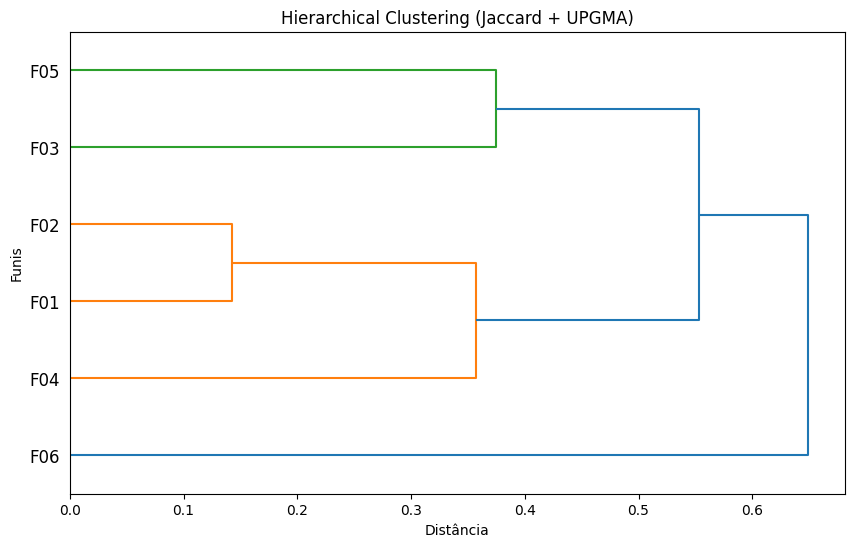

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(10,6))

dendrogram(
    Z,
    labels=df.index.tolist(),
    orientation='right' # Inverte a visualização para que os rótulos fiquem no eixo Y
)

plt.title("Hierarchical Clustering (Jaccard + UPGMA)")
plt.xlabel("Distância") # O eixo X agora representa a distância
plt.ylabel("Funis") # O eixo Y agora representa os funis
plt.show()

## Como a distância do dendrograma é calculada

A distância no dendrograma representa a **dissimilaridade** entre os 'funis' (neste caso, F01 a F06) ou entre grupos de funis. Essa distância é calculada em duas etapas principais:

1.  **Cálculo da Distância de Jaccard entre pares de funis**: Primeiro, calculamos a *distância de Jaccard* entre cada par individual de funis (por exemplo, F01 e F02, F01 e F03, etc.).
    *   **Distância de Jaccard**: É uma medida de dissimilaridade baseada na comparação de atributos binários (0s e 1s). Ela é calculada como `1 - Similaridade de Jaccard`. A Similaridade de Jaccard é a razão entre o número de atributos em comum (interseção) e o número total de atributos (união) entre dois funis. Quanto maior a distância de Jaccard, menos semelhantes são os funis.

2.  **Cálculo da Distância entre Clusters (UPGMA)**: Conforme o agrupamento hierárquico avança e os funis individuais começam a formar clusters (grupos), precisamos de uma maneira de medir a distância entre esses clusters recém-formados.
    *   **UPGMA (Unweighted Pair Group Method with Arithmetic Mean)**: Este método calcula a distância entre dois clusters como a *média das distâncias de Jaccard entre todas as combinações possíveis de elementos de um cluster com todos os elementos do outro cluster*. Em outras palavras, ele pega todas as distâncias de Jaccard já calculadas entre os membros dos dois clusters e tira a média.

No dendrograma, a **altura** na qual dois funis ou dois clusters se unem indica a distância (calculada pelo método UPGMA a partir das distâncias de Jaccard originais) na qual eles foram agrupados. Quanto maior a altura, maior a dissimilaridade entre os elementos ou clusters naquele ponto de união.